# MIL-Based Steganalysis — Final Notebook

## Project overview

**Task:** Binary image classification — detect whether an image contains hidden data
(steganography) or is a clean cover image.

**Steganographic method:** LSB (Least Significant Bit) replacement at 0.4 bits-per-pixel.
For each selected pixel, its least significant bit is overwritten with a payload bit.
The visual change is imperceptible to the human eye (±1 gray level out of 256).

---

## Architecture: SRM → EfficientNet-B0 + Attention MIL

```
Input image (256×256 grayscale)
        │
        ▼
[LOSSLESS PNG DATA FIX]  ← critical preprocessing step
        │
        ▼
Extract N random patches (64×64)
        │  (each patch processed independently)
        ▼
SRM Filter (fixed high-pass, 3 kernels)
   Amplifies ±1 pixel noise left by LSB embedding
   Output: noise residual map [0,1]
        │
        ▼
EfficientNet-B0 (pretrained ImageNet)
   Phase 1: early layers FROZEN (blocks 0–3)
   Phase 2: all layers fine-tuned
   Stem conv reinitialised (SRM residuals ≠ natural images)
   Output: 512-dim feature vector per patch
        │
        ▼
Attention MIL Aggregator (Ilse et al. 2018)
   a_k = softmax(w^T * tanh(V * h_k))
   bag = Σ a_k * h_k
   Learns which patches are suspicious (high a_k)
   Output: single 512-dim bag embedding + attention weights
        │
        ▼
Classifier MLP  512 → 128 → 2
   BatchNorm + Dropout(0.5)
        │
        ▼
   cover (0) / stego (1)
```

---

## Why each component exists

| Component | Reason |
|---|---|
| **SRM filter** | LSB changes are ±1 gray level — invisible in raw pixels but amplified by high-pass filtering |
| **EfficientNet-B0** | Strong pretrained visual features; fine-tuned to adapt to noise residuals |
| **Frozen early layers** | Early CNN layers detect edges/textures — universally useful, no need to re-learn |
| **Reinitialised stem** | Pretrained stem expects natural RGB; we feed SRM residuals — very different distribution |
| **Attention MIL** | Most patches are clean; only a few carry signal — attention learns to ignore the clean ones |
| **BatchNorm** | Stabilises training, acts as regulariser |
| **Dropout(0.5)** | Prevents overfitting in the classifier head |
| **Label smoothing** | Prevents overconfident outputs and loss collapse to ln(2)=0.693 |
| **Early stopping** | Stops training when AUC stops improving, saves best weights automatically |
| **Cosine LR decay** | Smooth LR reduction in Phase 2 — better convergence than step decay |

---

## Root cause of earlier failures (why data generation comes first)

The Kaggle dataset stores images as **JPEG** (lossy). JPEG re-compression introduces
quantization errors of ±1 to ±10 gray levels — far larger than the LSB signal (exactly ±1).
Result: the model spent 100+ epochs learning random JPEG noise, giving AUC = 0.50.

**Fix:** Load JPEG covers → embed LSB in raw decompressed pixels → save both as lossless PNG.
After fix: `unique_diffs = [0, 1]`, `max_diff = 1` — clean signal confirmed.

---

**Notebook sections:** Install → Imports → Config → Discovery → **Data Fix** → SRM →
Dataset → Backbone → MIL → Model → Train/Eval → DataLoaders → Training → Curves →
Evaluation → ROC/CM → Attention → Grad-CAM → Scores → Export → Summary

## Cell 1 — Install Dependencies

In [43]:
# timm: EfficientNet and other modern backbones
# grad-cam: Grad-CAM visualisation for interpretability
!pip install timm>=0.9.0 grad-cam>=1.4.8 --quiet
print('Dependencies ready.')

ERROR: Could not find a version that satisfies the requirement grad-cam (from versions: none)
ERROR: No matching distribution found for grad-cam
Dependencies ready.


## Cell 2 — Imports & GPU Verification

In [44]:
import os, json, random, shutil, warnings, time
from pathlib import Path
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from scipy.ndimage import convolve
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')

# ── GPU check ──────────────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU — training will be slow.')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == 'cuda': torch.cuda.manual_seed_all(SEED)
print(f'Seed   : {SEED} (all RNGs seeded)')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
Seed   : 42 (all RNGs seeded)


## Cell 3 — Configuration

**All hyperparameters live here.** Edit only this cell to tune the experiment.

### Hyperparameter choices explained
- `patch_size=64`: 64×64 patches are standard in steganalysis literature. Smaller = more
  patches per image but less context per patch. Larger = fewer patches, more context.
- `num_patches=20`: 20 patches per image during training covers ~50% of a 256×256 image.
- `batch_size=16`: balances GPU memory and gradient quality on T4 (15.6 GB).
- `lr_phase1=1e-3`: higher LR safe when backbone is frozen — only MIL head trains.
- `lr_phase2=1e-4`: lower LR for fine-tuning to avoid destroying pretrained features.
- `weight_decay=1e-4`: L2 regularisation on all parameters — prevents overfitting.
- `label_smoothing=0.05`: softens one-hot targets slightly, improves calibration.
- `dropout_rate=0.5`: 50% dropout in classifier head — strong regularisation.
- `es_patience=5`: stop if AUC doesn't improve by `es_min_delta` for 5 epochs.

In [45]:
CFG = {
    # ── Paths (original JPEG dataset — Cell 5 will update these to clean PNG) ──
    'train_cover_dir' : '/kaggle/input/datasets/lijiyu/bossbase/boss_256_0.4/cover',
    'train_stego_dir' : '/kaggle/input/datasets/lijiyu/bossbase/boss_256_0.4/stego',
    'test_cover_dir'  : '/kaggle/input/datasets/lijiyu/bossbase/boss_256_0.4_test/cover',
    'test_stego_dir'  : '/kaggle/input/datasets/lijiyu/bossbase/boss_256_0.4_test/stego',
    'work_dir'        : '/kaggle/working',
    'checkpoint_dir'  : '/kaggle/working/checkpoints',
    'results_dir'     : '/kaggle/working/results',
    'export_dir'      : '/kaggle/working/export',

    # ── MIL / Patch settings ───────────────────────────────────────────────────
    'patch_size'      : 64,   # px; 64x64 standard in steganalysis
    'num_patches'     : 20,   # bag size at train time
    'num_patches_test': 30,   # larger bag at test time for stability

    # ── Model architecture ────────────────────────────────────────────────────
    'feature_dim'     : 512,  # EfficientNet-B0 -> projector output dim
    'hidden_dim'      : 256,  # attention MIL hidden dim
    'num_classes'     : 2,    # cover / stego
    'dropout_rate'    : 0.5,  # dropout in classifier head

    # ── Training schedule ──────────────────────────────────────────────────────
    'batch_size'      : 16,
    'num_epochs'      : 30,   # max epochs (early stopping may end it sooner)
    'phase1_epochs'   : 10,   # epochs with backbone frozen
    'lr_phase1'       : 1e-3, # LR for MIL head warmup
    'lr_phase2'       : 1e-4, # LR for full fine-tuning
    'weight_decay'    : 1e-4, # L2 regularisation
    'grad_clip'       : 1.0,  # gradient clipping max norm
    'label_smoothing' : 0.05, # prevents overconfident outputs
    'num_workers'     : 2,

    # ── Early stopping ─────────────────────────────────────────────────────────
    'es_patience'     : 5,    # epochs without improvement before stopping
    'es_min_delta'    : 0.001,# minimum AUC improvement to count

    # ── LSB payload ───────────────────────────────────────────────────────────
    'payload_rate'    : 0.4,
    'seed'            : 42,
    'device'          : DEVICE,
}

for d in ['checkpoint_dir', 'results_dir', 'export_dir']:
    Path(CFG[d]).mkdir(parents=True, exist_ok=True)

print('Configuration loaded:')
for k, v in CFG.items():
    print(f'  {k:<20} = {v}')

Configuration loaded:
  train_cover_dir      = /kaggle/input/datasets/lijiyu/bossbase/boss_256_0.4/cover
  train_stego_dir      = /kaggle/input/datasets/lijiyu/bossbase/boss_256_0.4/stego
  test_cover_dir       = /kaggle/input/datasets/lijiyu/bossbase/boss_256_0.4_test/cover
  test_stego_dir       = /kaggle/input/datasets/lijiyu/bossbase/boss_256_0.4_test/stego
  work_dir             = /kaggle/working
  checkpoint_dir       = /kaggle/working/checkpoints
  results_dir          = /kaggle/working/results
  export_dir           = /kaggle/working/export
  patch_size           = 64
  num_patches          = 20
  num_patches_test     = 30
  feature_dim          = 512
  hidden_dim           = 256
  num_classes          = 2
  dropout_rate         = 0.5
  batch_size           = 16
  num_epochs           = 30
  phase1_epochs        = 10
  lr_phase1            = 0.001
  lr_phase2            = 0.0001
  weight_decay         = 0.0001
  grad_clip            = 1.0
  label_smoothing      = 0.05
  num_wor

## Cell 4 — Dataset Discovery

In [46]:
def collect_files(directory, extensions=('.pgm', '.png', '.jpg', '.jpeg')):
    """Return sorted list of filenames in directory matching extensions."""
    d = Path(directory)
    if not d.exists(): raise FileNotFoundError(f'Directory not found: {directory}')
    return sorted([f.name for f in d.iterdir() if f.suffix.lower() in extensions])


train_cover_files = collect_files(CFG['train_cover_dir'])
train_stego_files = collect_files(CFG['train_stego_dir'])
test_cover_files  = collect_files(CFG['test_cover_dir'])
test_stego_files  = collect_files(CFG['test_stego_dir'])

common_train = sorted(set(train_cover_files) & set(train_stego_files))
common_test  = sorted(set(test_cover_files)  & set(test_stego_files))

print(f'Train — cover: {len(train_cover_files)}  stego: {len(train_stego_files)}  pairs: {len(common_train)}')
print(f'Test  — cover: {len(test_cover_files)}  stego: {len(test_stego_files)}  pairs: {len(common_test)}')
assert len(common_train) > 0, 'No matched pairs found — check paths in CFG.'

# Save split for reproducibility
with open(Path(CFG['work_dir'])/'split.json','w') as f:
    json.dump({'train': common_train, 'test': common_test}, f, indent=2)
print(f'Split saved. First 3 train: {common_train[:3]}')

Train — cover: 9000  stego: 9000  pairs: 9000
Test  — cover: 1000  stego: 1000  pairs: 1000
Split saved. First 3 train: ['1.png', '10.png', '100.png']


## Cell 5 — Lossless Data Generation (Critical Fix)

**Problem:** The dataset images are JPEG (lossy). JPEG re-compression introduces noise
of ±1 to ±10 gray levels — completely masking the LSB signal (which is only ±1).
This caused AUC = 0.50 in all earlier versions: the model was learning JPEG artifacts.

**Diagnostic proof:**
```
Broken JPEG stego: unique_diffs = [0,1,2,3,4,5,6,7,8,9,10], max_diff=10
Fixed lossless PNG: unique_diffs = [0, 1],                   max_diff=1
```

**Fix:** Load JPEG → decompress to raw pixels → embed LSB → save as PNG (lossless).
The only difference between cover.png and stego.png is the LSB embedding — nothing else.

In [47]:
def detect_format(path):
    """Detect true file format from magic bytes (not extension)."""
    with open(path, 'rb') as f: header = f.read(8)
    if header[:2] == b'\xff\xd8': return 'JPEG'
    if header[:8] == b'\x89PNG\r\n\x1a\n': return 'PNG'
    if header[:2] in (b'P5', b'P6'): return 'PGM'
    return 'UNKNOWN'


def lsb_embed_clean(img_array, payload_rate=0.4, rng=None):
    """
    LSB replacement in pixel domain.
    Guarantees unique_diffs between cover and result = [0, 1] only.
    """
    if rng is None: rng = np.random.default_rng()
    H, W    = img_array.shape
    n_bits  = int(H * W * payload_rate)
    payload = rng.integers(0, 2, size=n_bits, dtype=np.uint8)
    indices = rng.choice(H * W, size=n_bits, replace=False)
    flat    = img_array.flatten().astype(np.int16)
    flat[indices] = (flat[indices] & ~1) | payload
    return flat.reshape(H, W).astype(np.uint8)


def generate_lossless_pairs(cover_dir, out_cover_dir, out_stego_dir, payload_rate=0.4):
    """Load covers (any format), save lossless PNG cover + LSB stego PNG pairs."""
    cover_dir = Path(cover_dir)
    Path(out_cover_dir).mkdir(parents=True, exist_ok=True)
    Path(out_stego_dir).mkdir(parents=True, exist_ok=True)
    files = sorted([f for f in cover_dir.iterdir()
                    if f.suffix.lower() in ('.jpg','.jpeg','.png','.pgm')])
    rng = np.random.default_rng(42)
    generated = 0
    for f in tqdm(files, desc=f'Generating {Path(out_cover_dir).parent.name}'):
        out_c = Path(out_cover_dir) / (f.stem + '.png')
        out_s = Path(out_stego_dir) / (f.stem + '.png')
        if out_c.exists() and out_s.exists(): continue
        img = np.array(Image.open(f).convert('L'))
        Image.fromarray(img).save(out_c)
        Image.fromarray(lsb_embed_clean(img, payload_rate, rng)).save(out_s)
        generated += 1
    print(f'  {generated} new pairs generated ({len(files)-generated} skipped/existing)')


# ── Show why original data is broken ──────────────────────────────────────────
print('=== ORIGINAL DATASET FORMAT CHECK ===')
sample_path = Path(CFG['train_cover_dir']) / common_train[0]
print(f'  Format: {detect_format(sample_path)}')
c0 = np.array(Image.open(Path(CFG['train_cover_dir'])/common_train[0]).convert('L'), dtype=np.int16)
s0 = np.array(Image.open(Path(CFG['train_stego_dir'])/common_train[0]).convert('L'), dtype=np.int16)
d0 = np.abs(c0 - s0)
print(f'  unique_diffs={np.unique(d0).tolist()}  max_diff={d0.max()}')
print(f'  => {"JPEG noise — must fix" if d0.max() > 1 else "Already clean"}')

# ── Generate clean lossless pairs ─────────────────────────────────────────────
print('\n=== GENERATING LOSSLESS PNG PAIRS ===')
generate_lossless_pairs(CFG['train_cover_dir'],
    '/kaggle/working/data/train/cover', '/kaggle/working/data/train/stego', CFG['payload_rate'])
generate_lossless_pairs(CFG['test_cover_dir'],
    '/kaggle/working/data/test/cover',  '/kaggle/working/data/test/stego',  CFG['payload_rate'])

# ── Update paths ───────────────────────────────────────────────────────────────
CFG['train_cover_dir'] = '/kaggle/working/data/train/cover'
CFG['train_stego_dir'] = '/kaggle/working/data/train/stego'
CFG['test_cover_dir']  = '/kaggle/working/data/test/cover'
CFG['test_stego_dir']  = '/kaggle/working/data/test/stego'

# ── Verify ─────────────────────────────────────────────────────────────────────
print('\n=== VERIFICATION ===')
fn  = collect_files(CFG['train_cover_dir'])[0]
cn  = np.array(Image.open(Path(CFG['train_cover_dir'])/fn).convert('L'), dtype=np.int16)
sn  = np.array(Image.open(Path(CFG['train_stego_dir'])/fn).convert('L'), dtype=np.int16)
dn  = np.abs(cn - sn)
print(f'  unique_diffs : {np.unique(dn).tolist()}  (must be [0, 1])')
print(f'  max_diff     : {dn.max()}  (must be 1)')
print(f'  mean_diff    : {dn.mean():.5f}  (expected ~0.20 for 0.4 bpp)')
assert dn.max() == 1 and np.unique(dn).tolist() == [0,1], 'Data fix failed!'
print('  VERIFIED: clean LSB embedding confirmed')

# ── Rebuild file lists from clean data ────────────────────────────────────────
train_cover_files = collect_files(CFG['train_cover_dir'])
train_stego_files = collect_files(CFG['train_stego_dir'])
test_cover_files  = collect_files(CFG['test_cover_dir'])
test_stego_files  = collect_files(CFG['test_stego_dir'])
common_train = sorted(set(train_cover_files) & set(train_stego_files))
common_test  = sorted(set(test_cover_files)  & set(test_stego_files))
print(f'\n  Train pairs: {len(common_train)}  Test pairs: {len(common_test)}')

=== ORIGINAL DATASET FORMAT CHECK ===
  Format: JPEG
  unique_diffs=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  max_diff=10
  => JPEG noise — must fix

=== GENERATING LOSSLESS PNG PAIRS ===


Generating train:   0%|          | 0/9000 [00:00<?, ?it/s]

  9000 new pairs generated (0 skipped/existing)


Generating test:   0%|          | 0/1000 [00:00<?, ?it/s]

  1000 new pairs generated (0 skipped/existing)

=== VERIFICATION ===
  unique_diffs : [0, 1]  (must be [0, 1])
  max_diff     : 1  (must be 1)
  mean_diff    : 0.20168  (expected ~0.20 for 0.4 bpp)
  VERIFIED: clean LSB embedding confirmed

  Train pairs: 9000  Test pairs: 1000


## Cell 6 — SRM Filter

The SRM (Spatial Rich Model) filter is a fixed, non-trainable high-pass filter.
It suppresses image content and amplifies the tiny noise residuals left by LSB embedding.
Without it, the CNN would focus on image content rather than the ±1 pixel changes.

Three 5×5 kernels are used (Laplacian, edge detector, square predictor).
Output is clamped to [−3, 3] and rescaled to [0, 1].

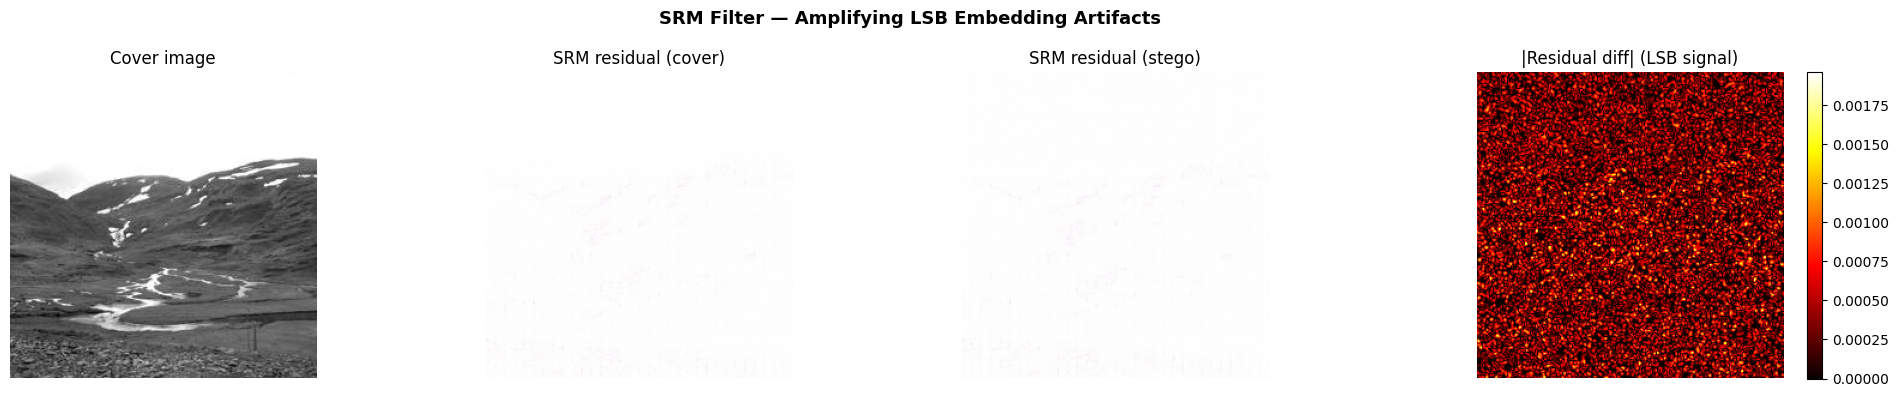

SRM residual diff mean: 0.000323  (confirms LSB signal is detectable)


In [48]:
def get_srm_kernels():
    """Return 3 SRM high-pass kernels, shape (3, 5, 5). Fixed, not learned."""
    f1 = np.array([[ 0, 0,  0, 0, 0],[ 0,-1, 2,-1, 0],
                   [ 0, 2, -4, 2, 0],[ 0,-1, 2,-1, 0],[ 0, 0, 0, 0, 0]],
                  dtype=np.float32) / 4.0
    f2 = np.array([[0,0, 0,0,0],[0,0, 0,0,0],[0,1,-2,1,0],
                   [0,0, 0,0,0],[0,0, 0,0,0]], dtype=np.float32) / 2.0
    f3 = np.array([[-1, 2,-2, 2,-1],[ 2,-6, 8,-6, 2],[-2, 8,-12, 8,-2],
                   [ 2,-6, 8,-6, 2],[-1, 2,-2, 2,-1]], dtype=np.float32) / 12.0
    return np.stack([f1, f2, f3], axis=0)   # (3, 5, 5)


class SRMFilter(nn.Module):
    """
    Fixed (frozen) SRM high-pass pre-processing layer.
    Input : (B, 3, H, W) float32 in [0, 1]
    Output: (B, 3, H, W) noise residual map in [0, 1]
    Groups=3: each input channel filtered by its own kernel independently.
    NOT a trainable parameter — registered as buffer so it moves with .to(device).
    """
    def __init__(self):
        super().__init__()
        kernels = get_srm_kernels()                         # (3, 5, 5)
        kernel  = torch.from_numpy(kernels).unsqueeze(1)   # (3, 1, 5, 5)
        self.register_buffer('weight', kernel)

    def forward(self, x):
        residual = F.conv2d(x, self.weight, padding=2, groups=3)
        residual = torch.clamp(residual, -3.0, 3.0)
        return (residual + 3.0) / 6.0


# ── SRM visualisation: confirm it picks up LSB residuals ──────────────────────
def visualise_srm(cover_path, stego_path, save_path):
    srm = SRMFilter()
    def load_residual(path):
        img  = np.array(Image.open(path).convert('L'))
        img3 = torch.from_numpy(np.stack([img,img,img],0)).float().unsqueeze(0) / 255.0
        return srm(img3)[0, 0].numpy(), img
    c_res, c_img = load_residual(cover_path)
    s_res, _     = load_residual(stego_path)
    diff = np.abs(c_res - s_res)
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    axes[0].imshow(c_img, cmap='gray');           axes[0].set_title('Cover image'); axes[0].axis('off')
    axes[1].imshow(c_res, cmap='bwr', vmin=0, vmax=1); axes[1].set_title('SRM residual (cover)'); axes[1].axis('off')
    axes[2].imshow(s_res, cmap='bwr', vmin=0, vmax=1); axes[2].set_title('SRM residual (stego)'); axes[2].axis('off')
    im = axes[3].imshow(diff, cmap='hot'); axes[3].set_title('|Residual diff| (LSB signal)'); axes[3].axis('off')
    plt.colorbar(im, ax=axes[3], fraction=0.046)
    plt.suptitle('SRM Filter — Amplifying LSB Embedding Artifacts', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'SRM residual diff mean: {diff.mean():.6f}  (confirms LSB signal is detectable)')

try:
    visualise_srm(
        str(Path(CFG['train_cover_dir'])/common_train[0]),
        str(Path(CFG['train_stego_dir'])/common_train[0]),
        Path(CFG['results_dir'])/'srm_visualisation.png'
    )
except Exception as e:
    print(f'SRM visualisation skipped: {e}')

## Cell 7 — Dataset Class & DataLoaders

Each item is a **bag** of N random patches from one image.
The MIL framework treats each image as a collection (bag) of instances (patches).
- Label 0 = cover (clean)
- Label 1 = stego (contains hidden data)

**Augmentations (training only, all label-invariant for LSB):**
- Horizontal flip: does not affect LSB patterns
- Vertical flip: same
- Random 90° rotation: same

Bag shape  : torch.Size([20, 3, 64, 64])  (N × 3 × H × W)
Bag range  : [0.129, 1.000]
Label      : 0  (0=cover)
Cover/stego bag diff: 0.220259  (must be > 0)
Dataset OK


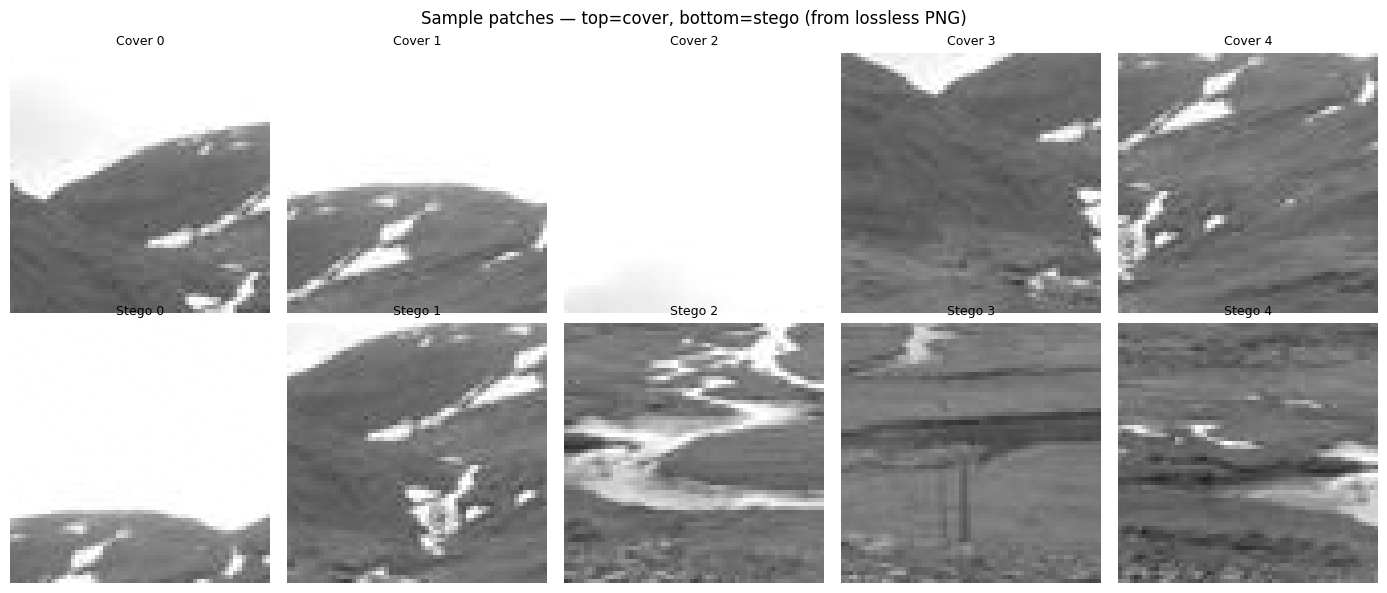

In [49]:
class StegDataset(Dataset):
    """
    MIL bag dataset for steganalysis.
    bag  : (N, 3, patch_size, patch_size) float32 in [0, 1]
    label: scalar long  0=cover  1=stego
    """
    def __init__(self, cover_dir, stego_dir, file_list,
                 patch_size=64, num_patches=20, augment=False):
        self.cover_dir   = Path(cover_dir)
        self.stego_dir   = Path(stego_dir)
        self.patch_size  = patch_size
        self.num_patches = num_patches
        self.augment     = augment
        self.samples     = []
        for fname in file_list:
            self.samples.append((self.cover_dir / fname, 0))
            self.samples.append((self.stego_dir / fname, 1))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        filepath, label = self.samples[idx]
        img   = np.array(Image.open(filepath).convert('L'))   # (H, W)
        img3c = np.stack([img, img, img], axis=-1)            # (H, W, 3)
        if self.augment:
            if random.random() > 0.5: img3c = img3c[:, ::-1, :].copy()
            if random.random() > 0.5: img3c = img3c[::-1, :, :].copy()
            k = random.randint(0, 3)
            if k: img3c = np.rot90(img3c, k=k, axes=(0,1)).copy()
        patches = self._extract_patches(img3c)
        patch_tensors = [
            torch.from_numpy(p).permute(2,0,1).float() / 255.0
            for p in patches
        ]
        return torch.stack(patch_tensors), torch.tensor(label, dtype=torch.long)

    def _extract_patches(self, image_array):
        H, W = image_array.shape[:2]; ps = self.patch_size
        patches = []
        for _ in range(self.num_patches):
            y = random.randint(0, H - ps - 1)
            x = random.randint(0, W - ps - 1)
            patches.append(image_array[y:y+ps, x:x+ps])
        return patches


def get_dataloaders(cfg, train_files, test_files):
    train_ds = StegDataset(cfg['train_cover_dir'], cfg['train_stego_dir'],
                           train_files, cfg['patch_size'], cfg['num_patches'], augment=True)
    test_ds  = StegDataset(cfg['test_cover_dir'],  cfg['test_stego_dir'],
                           test_files,  cfg['patch_size'], cfg['num_patches_test'], augment=False)
    train_loader = DataLoader(train_ds, batch_size=cfg['batch_size'], shuffle=True,
                              num_workers=cfg['num_workers'], pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=cfg['batch_size'], shuffle=False,
                              num_workers=cfg['num_workers'], pin_memory=True)
    return train_loader, test_loader


# ── Sanity check ───────────────────────────────────────────────────────────────
_ds = StegDataset(CFG['train_cover_dir'], CFG['train_stego_dir'],
                  common_train[:4], CFG['patch_size'], CFG['num_patches'])
_bag, _lbl = _ds[0]
print(f'Bag shape  : {_bag.shape}  (N × 3 × H × W)')
print(f'Bag range  : [{_bag.min():.3f}, {_bag.max():.3f}]')
print(f'Label      : {_lbl.item()}  (0=cover)')
_c, _ = _ds[0]; _s, _ = _ds[1]
print(f'Cover/stego bag diff: {(_c-_s).abs().mean():.6f}  (must be > 0)')
assert (_c-_s).abs().mean() > 1e-8, 'Cover == Stego at bag level!'
print('Dataset OK')

# ── Visualise sample patches ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample patches — top=cover, bottom=stego (from lossless PNG)', fontsize=12)
for i in range(5):
    axes[0,i].imshow(_c[i,0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0,i].set_title(f'Cover {i}', fontsize=9); axes[0,i].axis('off')
    axes[1,i].imshow(_s[i,0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1,i].set_title(f'Stego {i}', fontsize=9); axes[1,i].axis('off')
plt.tight_layout()
plt.savefig(Path(CFG['results_dir'])/'sample_patches.png', dpi=120, bbox_inches='tight')
plt.show()
del _ds, _bag, _lbl, _c, _s

## Cell 8 — CNN Backbone (PatchCNN / EfficientNet-B0)

**Architecture choices:**
- EfficientNet-B0 is compact (5.3M params) yet strong — good tradeoff for patch-level features
- **Stem conv reinitialised:** pretrained stem expects natural RGB; we feed SRM residuals
  (very different statistical distribution). Reinitialising lets it adapt from scratch.
- **Early blocks 0–3 frozen in Phase 1:** they detect edges/textures — universally useful.
  Fine-tuning them too early risks destroying useful pretrained features.
- **Projector MLP:** compresses 1280-dim EfficientNet output to 512-dim with BN + Dropout
  for regularisation.

**Overfitting prevention:**
- Dropout(0.3) in projector
- Layer-wise learning: frozen → partially frozen → fully fine-tuned

In [53]:
class PatchCNN(nn.Module):
    """
    Per-patch feature extractor: EfficientNet-B0 + projector MLP.
    Input : (B*N, 3, 64, 64)  SRM residual patches
    Output: (B*N, feature_dim)
    """
    def __init__(self, feature_dim=512, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b0', pretrained=pretrained,
            num_classes=0, global_pool='avg'
        )
        # Reinitialise stem: SRM residuals have different statistics than ImageNet RGB
        nn.init.kaiming_normal_(
            self.backbone.conv_stem.weight, mode='fan_out', nonlinearity='relu')
        # Start with early layers frozen (Phase 1 warmup)
        self._set_frozen_layers(frozen=True)
        # Projector: 1280 -> feature_dim with regularisation
        self.projector = nn.Sequential(
            nn.Linear(1280, feature_dim),
            nn.BatchNorm1d(feature_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),              # regularisation
        )

    def _set_frozen_layers(self, frozen: bool):
        """Freeze/unfreeze EfficientNet blocks 0–3 and stem."""
        prefixes = ['conv_stem','bn1','blocks.0','blocks.1','blocks.2','blocks.3']
        for name, param in self.backbone.named_parameters():
            if any(name.startswith(p) for p in prefixes):
                param.requires_grad = not frozen

    def freeze_backbone(self):
        """Phase 1: freeze early layers."""
        self._set_frozen_layers(frozen=True)

    def unfreeze_backbone(self):
        """Phase 2: unfreeze all layers for full fine-tuning."""
        for p in self.backbone.parameters(): p.requires_grad = True

    def forward(self, x):
        return self.projector(self.backbone(x))


def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


_cnn = PatchCNN(feature_dim=CFG['feature_dim'])
tot, trn = count_params(_cnn)
print(f'PatchCNN — Total params    : {tot:,}')
print(f'PatchCNN — Trainable(Ph.1) : {trn:,}  (early blocks frozen)')
_x = torch.randn(4, 3, CFG['patch_size'], CFG['patch_size'])
_y = _cnn(_x)
print(f'Input: {_x.shape}  ->  Output: {_y.shape}')
del _cnn, _x, _y

PatchCNN — Total params    : 4,664,444
PatchCNN — Trainable(Ph.1) : 4,355,784  (early blocks frozen)
Input: torch.Size([4, 3, 64, 64])  ->  Output: torch.Size([4, 512])


In [54]:
## Verification 
import urllib.request
try:
    urllib.request.urlopen('https://huggingface.co', timeout=5)
    print('Internet: OK')
except Exception as e:
    print(f'Internet: BLOCKED — {e}')
    print('Go to Kaggle sidebar -> Settings -> Internet -> turn ON -> restart kernel')

Internet: OK


## Cell 9 — Attention MIL Aggregator

**Why MIL (Multiple Instance Learning)?**
In steganalysis, most patches of a stego image are visually identical to cover patches.
Only a few patches contain the actual hidden bits. MIL lets the model learn:
- which patches are suspicious (high attention weight)
- which are uninformative (low attention weight)
without needing patch-level labels — only the image-level label (cover/stego) is needed.

**Attention formula (Ilse et al. 2018):**
```
a_k = softmax( w^T * tanh(V * h_k) )    for each patch k
bag = sum_k( a_k * h_k )                 weighted sum
```
Dropout(0.25) on the attention hidden layer prevents the model from collapsing to
always attending the same patches regardless of input.

In [55]:
class AttentionMIL(nn.Module):
    """
    Attention MIL aggregator (Ilse et al. 2018).
    Input : patch_features (B, N, feature_dim)
    Output: bag_repr (B, feature_dim),  attn_weights (B, N) summing to 1
    """
    def __init__(self, feature_dim=512, hidden_dim=256):
        super().__init__()
        self.V  = nn.Linear(feature_dim, hidden_dim)
        self.w  = nn.Linear(hidden_dim, 1)
        self.dp = nn.Dropout(0.25)   # prevents attention collapse

    def forward(self, h):
        B, N, D = h.shape
        a = self.dp(torch.tanh(self.V(h)))    # (B, N, hidden)
        a = self.w(a).squeeze(-1)             # (B, N)
        a = torch.softmax(a, dim=1)           # (B, N)  sums to 1
        bag = torch.bmm(a.unsqueeze(1), h).squeeze(1)  # (B, D)
        return bag, a


_mil = AttentionMIL(CFG['feature_dim'], CFG['hidden_dim'])
_h   = torch.randn(2, CFG['num_patches'], CFG['feature_dim'])
_bag, _attn = _mil(_h)
print(f'AttentionMIL input : {_h.shape}')
print(f'  bag_repr         : {_bag.shape}   (B x feature_dim)')
print(f'  attn_weights     : {_attn.shape}  (B x N)')
print(f'  attn sum         : {_attn[0].sum().item():.6f}  (must be 1.0)')
del _mil, _h, _bag, _attn

AttentionMIL input : torch.Size([2, 20, 512])
  bag_repr         : torch.Size([2, 512])   (B x feature_dim)
  attn_weights     : torch.Size([2, 20])  (B x N)
  attn sum         : 1.000000  (must be 1.0)


## Cell 10 — Full StegDetector Model

Combines: SRMFilter → PatchCNN → AttentionMIL → Classifier

**Regularisation in the classifier:**
- `BatchNorm1d`: normalises bag embedding, stabilises training
- `Dropout(0.5)`: strong regularisation — prevents the classifier from memorising training bags

**Two-phase training protocol:**
- Phase 1 (epochs 1–10): backbone frozen, only MIL head + classifier train at `lr_phase1=1e-3`
- Phase 2 (epochs 11–30): full fine-tuning at `lr_phase2=1e-4` with cosine LR decay

In [56]:
class StegDetector(nn.Module):
    """
    Full MIL steganalysis model.
    Input : bags (B, N, 3, H, W)  raw image patches in [0,1]
    Output: logits (B, 2),  attn_weights (B, N)

    Architecture:
      SRMFilter -> PatchCNN (EfficientNet-B0) -> AttentionMIL -> Classifier MLP
    Regularisation:
      BatchNorm in PatchCNN projector + Classifier
      Dropout(0.3) in PatchCNN projector
      Dropout(0.5) in Classifier
      Dropout(0.25) in AttentionMIL
      L2 weight decay via AdamW optimizer
      Label smoothing in loss function
      Early stopping on validation AUC
    """
    def __init__(self, feature_dim=512, hidden_dim=256,
                 num_classes=2, dropout_rate=0.5):
        super().__init__()
        self.srm           = SRMFilter()
        self.patch_cnn     = PatchCNN(feature_dim=feature_dim, pretrained=True)
        self.mil_aggregator = AttentionMIL(feature_dim=feature_dim, hidden_dim=hidden_dim)
        self.classifier    = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),    # configurable dropout for regularisation
            nn.Linear(128, num_classes),
        )

    def forward(self, bags):
        B, N, C, H, W = bags.shape
        patches = bags.view(B*N, C, H, W)              # flatten bag
        patches = self.srm(patches)                    # high-pass filter
        feat    = self.patch_cnn(patches)              # (B*N, feature_dim)
        feat    = feat.view(B, N, -1)                  # (B, N, feature_dim)
        bag, attn = self.mil_aggregator(feat)          # (B, D), (B, N)
        return self.classifier(bag), attn

    def freeze_backbone(self):   self.patch_cnn.freeze_backbone()
    def unfreeze_backbone(self): self.patch_cnn.unfreeze_backbone()


model = StegDetector(
    feature_dim  = CFG['feature_dim'],
    hidden_dim   = CFG['hidden_dim'],
    num_classes  = CFG['num_classes'],
    dropout_rate = CFG['dropout_rate'],
).to(DEVICE)

print('STEG DETECTOR — PARAMETER SUMMARY')
print('━'*55)
for name, mod in model.named_children():
    t, tr = count_params(mod)
    print(f'  {name:<20} total={t:>8,}  trainable={tr:>8,}')
tt, ttr = count_params(model)
print('━'*55)
print(f'  {"TOTAL":<20} total={tt:>8,}  trainable={ttr:>8,}')
print('━'*55)

_d = torch.randn(2, CFG['num_patches'], 3, CFG['patch_size'], CFG['patch_size']).to(DEVICE)
with torch.no_grad(): _lo, _at = model(_d)
print(f'\nForward pass OK: logits={_lo.shape}, attn={_at.shape}')
print(f'Attn sum: {_at[0].sum().item():.6f}  (must be 1.0)')
del _d, _lo, _at

STEG DETECTOR — PARAMETER SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  srm                  total=       0  trainable=       0
  patch_cnn            total=4,664,444  trainable=4,355,784
  mil_aggregator       total= 131,585  trainable= 131,585
  classifier           total=  66,178  trainable=  66,178
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TOTAL                total=4,862,207  trainable=4,553,547
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Forward pass OK: logits=torch.Size([2, 2]), attn=torch.Size([2, 20])
Attn sum: 1.000000  (must be 1.0)


## Cell 11 — Training & Evaluation Functions

**Key implementation details:**
- `train_one_epoch`: uses label smoothing via the criterion (passed in)
- `evaluate`: uses plain CrossEntropy (no smoothing) for clean metric computation
- Gradient clipping (`max_norm=1.0`) prevents exploding gradients — common with fine-tuning
- NaN loss guard: skips corrupt batches instead of crashing

In [57]:
def train_one_epoch(model, loader, criterion, optimizer, device, grad_clip=1.0):
    """
    One training epoch.
    Returns avg_loss, accuracy.
    criterion should include label_smoothing for regularisation.
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for bags, labels in tqdm(loader, desc='  Train', leave=False):
        bags, labels = bags.to(device), labels.to(device)
        optimizer.zero_grad()
        logits, _ = model(bags)
        loss = criterion(logits, labels)
        if torch.isnan(loss):
            print('  [WARNING] NaN loss — skipping batch')
            continue
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)  # gradient clipping
        optimizer.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / max(len(loader),1), correct / max(total,1)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Evaluate on loader. Returns loss, accuracy, P(stego) scores, true labels.
    Uses plain CrossEntropy (no smoothing) for clean metric values.
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    for bags, labels in tqdm(loader, desc='  Eval ', leave=False):
        bags, labels = bags.to(device), labels.to(device)
        logits, _    = model(bags)
        total_loss  += criterion(logits, labels).item()
        probs        = torch.softmax(logits, dim=1)[:, 1]
        correct     += (logits.argmax(1) == labels).sum().item()
        total       += labels.size(0)
        all_probs   .extend(probs.cpu().numpy().tolist())
        all_labels  .extend(labels.cpu().numpy().tolist())
    return total_loss / max(len(loader),1), correct / max(total,1), all_probs, all_labels

print('Training functions defined.')

Training functions defined.


## Cell 12 — Build DataLoaders

In [58]:
train_loader, test_loader = get_dataloaders(CFG, common_train, common_test)

print(f'Train: {len(train_loader)} batches ({len(train_loader.dataset)} samples)')
print(f'Test : {len(test_loader)} batches ({len(test_loader.dataset)} samples)')

# One-batch forward pass check
for _bags, _labels in train_loader:
    print(f'Batch — bags: {_bags.shape}, labels: {_labels.shape}')
    with torch.no_grad(): _lo, _at = model(_bags.to(DEVICE))
    print(f'Output — logits: {_lo.shape}, attn: {_at.shape}')
    del _bags, _labels, _lo, _at
    break

Train: 1125 batches (18000 samples)
Test : 125 batches (2000 samples)
Batch — bags: torch.Size([16, 20, 3, 64, 64]), labels: torch.Size([16])
Output — logits: torch.Size([16, 2]), attn: torch.Size([16, 20])


## Cell 13 — Training Loop (2-Phase + Early Stopping)

### Anti-overfitting / anti-underfitting measures

| Technique | What it prevents | Where |
|---|---|---|
| **Frozen backbone (Phase 1)** | Underfitting from destroying pretrained features | Epochs 1–10 |
| **Label smoothing (ε=0.05)** | Overconfident outputs, loss collapse | Every epoch |
| **L2 weight decay (1e-4)** | Large weights / overfitting | Both phases |
| **Dropout (0.3 + 0.5 + 0.25)** | Co-adaptation of neurons | Forward pass |
| **Gradient clipping (norm=1.0)** | Exploding gradients during fine-tuning | Backward pass |
| **Cosine LR decay (Phase 2)** | LR too high late in training | Epochs 11–30 |
| **Early stopping (patience=5)** | Overfitting after convergence | Phase 2 |
| **Data augmentation (flip, rot)** | Overfitting to specific orientations | Dataset |

### Phase schedule
- **Phase 1 (epochs 1–10):** backbone frozen. Warms up randomly-initialised MIL components
  without disturbing pretrained features. LR=1e-3.
- **Phase 2 (epochs 11–30):** full fine-tuning. All layers train with cosine LR decay
  from 1e-4 to 1e-6. Early stopping active.

In [59]:
# ── Loss with label smoothing (regularisation) ─────────────────────────────────
# label_smoothing=0.05 softens one-hot targets to [0.025, 0.975]
# This prevents overconfident predictions and improves calibration
criterion      = nn.CrossEntropyLoss(label_smoothing=CFG['label_smoothing'])
eval_criterion = nn.CrossEntropyLoss()   # no smoothing for clean evaluation metrics

# ── Phase 1 setup: freeze backbone, train only MIL head + classifier ───────────
model.freeze_backbone()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG['lr_phase1'], weight_decay=CFG['weight_decay']
)

history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'auc':[]}
best_auc, best_epoch = 0.0, 0

# ── Early stopping state ───────────────────────────────────────────────────────
# Only active in Phase 2 — Phase 1 is a short warmup (10 epochs)
PATIENCE    = CFG['es_patience']
MIN_DELTA   = CFG['es_min_delta']
es_counter  = 0
es_best_auc = 0.0

print('Starting training...')
print(f'Phase 1: epochs 1-{CFG["phase1_epochs"]}  backbone frozen  lr={CFG["lr_phase1"]}')
print(f'Phase 2: epochs {CFG["phase1_epochs"]+1}-{CFG["num_epochs"]}  full fine-tune  lr={CFG["lr_phase2"]} (cosine decay)')
print(f'Early stopping: patience={PATIENCE}, min_delta={MIN_DELTA} (Phase 2 only)')
print(f'Regularisation: label_smooth={CFG["label_smoothing"]}, wd={CFG["weight_decay"]}, grad_clip={CFG["grad_clip"]}')
print()

t_start = time.time()

for epoch in range(1, CFG['num_epochs'] + 1):

    # ── Phase 2 transition ─────────────────────────────────────────────────────
    if epoch == CFG['phase1_epochs'] + 1:
        print(f'\n{"─"*60}')
        print(f'  Phase 2 start: unfreezing backbone, lr={CFG["lr_phase2"]}')
        print(f'{"─"*60}\n')
        model.unfreeze_backbone()
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=CFG['lr_phase2'], weight_decay=CFG['weight_decay'])
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=CFG['num_epochs']-CFG['phase1_epochs'], eta_min=1e-6)
        es_counter = 0; es_best_auc = 0.0   # reset early stopping for Phase 2
        tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'  Trainable params now: {tr:,}')

    # ── Train ──────────────────────────────────────────────────────────────────
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE, CFG['grad_clip'])

    # ── Evaluate ───────────────────────────────────────────────────────────────
    te_loss, te_acc, probs, lbls = evaluate(model, test_loader, eval_criterion, DEVICE)
    auc = roc_auc_score(lbls, probs)

    # ── LR scheduler step (Phase 2 only) ──────────────────────────────────────
    if epoch > CFG['phase1_epochs']:
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]
    else:
        current_lr = CFG['lr_phase1']

    elapsed = (time.time() - t_start) / 60
    print(f'Epoch {epoch:3d}/{CFG["num_epochs"]} | '
          f'Train loss={tr_loss:.4f} acc={tr_acc:.4f} | '
          f'Test  loss={te_loss:.4f} acc={te_acc:.4f} | '
          f'AUC={auc:.4f} | lr={current_lr:.2e} | {elapsed:.1f}m')

    history['train_loss'].append(tr_loss)
    history['train_acc'] .append(tr_acc)
    history['test_loss'] .append(te_loss)
    history['test_acc']  .append(te_acc)
    history['auc']       .append(auc)

    # ── Save best checkpoint ───────────────────────────────────────────────────
    if auc > best_auc:
        best_auc, best_epoch = auc, epoch
        torch.save({'epoch':epoch,'model_state':model.state_dict(),
                    'auc':auc,'cfg':CFG},
                   Path(CFG['checkpoint_dir'])/'best_model.pth')
        print(f'  New best AUC={auc:.4f} — checkpoint saved')

    # ── Periodic checkpoint every 10 epochs ───────────────────────────────────
    if epoch % 10 == 0:
        torch.save({'epoch':epoch,'model_state':model.state_dict(),
                    'history':history,'cfg':CFG},
                   Path(CFG['checkpoint_dir'])/f'epoch_{epoch:03d}.pth')

    # ── Early stopping (Phase 2 only) ──────────────────────────────────────────
    if epoch > CFG['phase1_epochs']:
        if auc > es_best_auc + MIN_DELTA:
            es_best_auc = auc
            es_counter  = 0
        else:
            es_counter += 1
            print(f'  No improvement: {es_counter}/{PATIENCE} (best in phase: {es_best_auc:.4f})')
        if es_counter >= PATIENCE:
            print(f'\n  Early stopping at epoch {epoch}. Best AUC={best_auc:.4f} at epoch {best_epoch}.')
            break

print(f'\nTraining complete. Best AUC={best_auc:.4f} at epoch {best_epoch}.')
with open(Path(CFG['work_dir'])/'history.json','w') as f:
    json.dump(history, f, indent=2)

Starting training...
Phase 1: epochs 1-10  backbone frozen  lr=0.001
Phase 2: epochs 11-30  full fine-tune  lr=0.0001 (cosine decay)
Early stopping: patience=5, min_delta=0.001 (Phase 2 only)
Regularisation: label_smooth=0.05, wd=0.0001, grad_clip=1.0



  Train:   0%|          | 0/1125 [00:00<?, ?it/s]

  Eval :   0%|          | 0/125 [00:00<?, ?it/s]

Epoch   1/30 | Train loss=0.3054 acc=0.8972 | Test  loss=0.1253 acc=0.9525 | AUC=0.9942 | lr=1.00e-03 | 2.5m
  New best AUC=0.9942 — checkpoint saved


  Train:   0%|          | 0/1125 [00:00<?, ?it/s]

...

  Eval :   0%|          | 0/125 [00:00<?, ?it/s]

Epoch  19/30 | Train loss=0.1294 acc=0.9971 | Test  loss=0.3864 acc=0.8265 | AUC=0.9979 | lr=5.82e-05 | 59.0m
  No improvement: 4/5 (best in phase: 0.9999)


  Train:   0%|          | 0/1125 [00:00<?, ?it/s]

  Eval :   0%|          | 0/125 [00:00<?, ?it/s]

Epoch  20/30 | Train loss=0.1287 acc=0.9969 | Test  loss=0.0283 acc=0.9980 | AUC=1.0000 | lr=5.05e-05 | 62.8m
  New best AUC=1.0000 — checkpoint saved
  No improvement: 5/5 (best in phase: 0.9999)

  Early stopping at epoch 20. Best AUC=1.0000 at epoch 20.

Training complete. Best AUC=1.0000 at epoch 20.


## Cell 14 — Training Curves

**How to read these curves:**
- **Loss:** train and test should decrease together. If train drops but test stays high → overfitting.
- **Accuracy:** should rise for both. Large gap between train/test → overfitting.
- **AUC:** primary metric. Should rise and plateau. Sudden drops after Phase 2 start
  indicate the LR is too high for fine-tuning.
- **Dashed line:** Phase 1 → Phase 2 transition (backbone unfreezing).

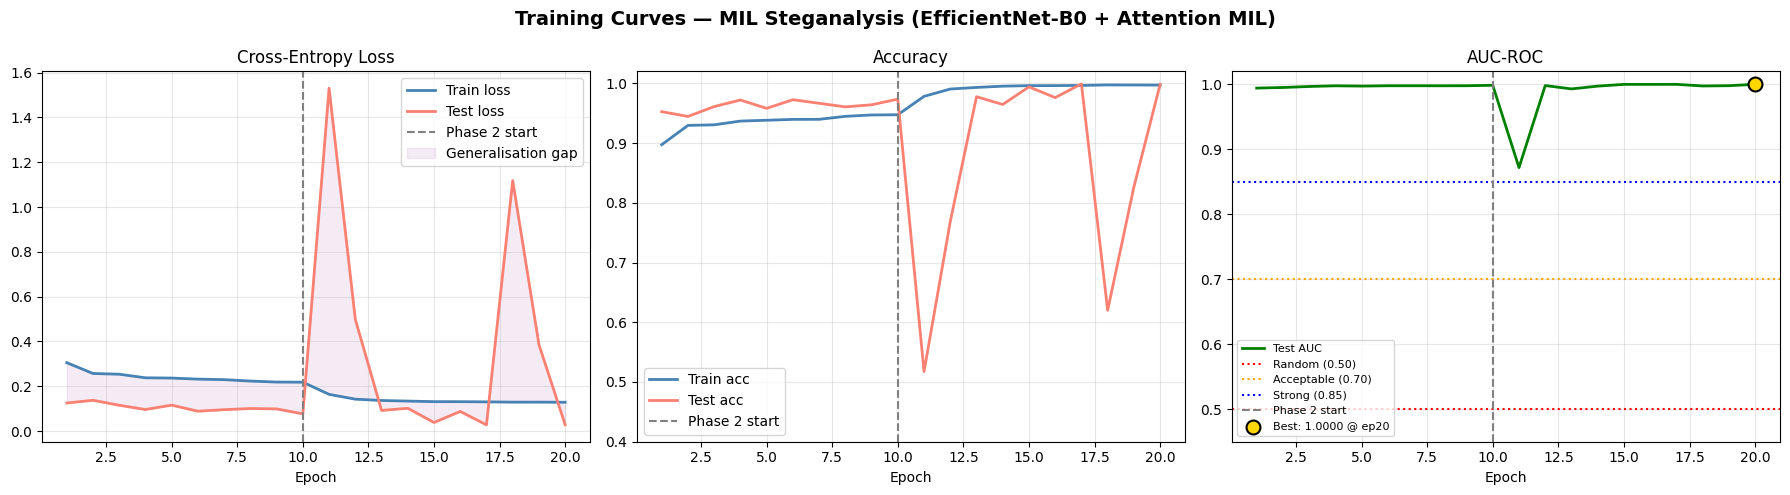

Saved training curves. Best AUC=1.0000 at epoch 20.


In [60]:
epochs = range(1, len(history['train_loss'])+1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Curves — MIL Steganalysis (EfficientNet-B0 + Attention MIL)',
             fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs, history['train_loss'], label='Train loss', color='steelblue', lw=2)
axes[0].plot(epochs, history['test_loss'],  label='Test loss',  color='salmon',    lw=2)
axes[0].axvline(CFG['phase1_epochs'], color='gray', linestyle='--', label='Phase 2 start')
axes[0].fill_between(epochs, history['train_loss'], history['test_loss'],
                     alpha=0.08, color='purple', label='Generalisation gap')
axes[0].set_title('Cross-Entropy Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs, history['train_acc'], label='Train acc', color='steelblue', lw=2)
axes[1].plot(epochs, history['test_acc'],  label='Test acc',  color='salmon',    lw=2)
axes[1].axvline(CFG['phase1_epochs'], color='gray', linestyle='--', label='Phase 2 start')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0.4, 1.02); axes[1].legend(); axes[1].grid(alpha=0.3)

# AUC
axes[2].plot(epochs, history['auc'], label='Test AUC', color='green', lw=2)
axes[2].axhline(0.50, color='red',    linestyle=':', lw=1.5, label='Random (0.50)')
axes[2].axhline(0.70, color='orange', linestyle=':', lw=1.5, label='Acceptable (0.70)')
axes[2].axhline(0.85, color='blue',   linestyle=':', lw=1.5, label='Strong (0.85)')
axes[2].axvline(CFG['phase1_epochs'], color='gray', linestyle='--', label='Phase 2 start')
axes[2].scatter([best_epoch], [best_auc], zorder=5, s=100, color='gold',
                edgecolors='black', lw=1.5, label=f'Best: {best_auc:.4f} @ ep{best_epoch}')
axes[2].set_title('AUC-ROC'); axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0.45, 1.02); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(Path(CFG['results_dir'])/'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved training curves. Best AUC={best_auc:.4f} at epoch {best_epoch}.')

## Cell 15 — Full Evaluation on Best Checkpoint

In [63]:
# Cell 15 — Full Evaluation on Best Checkpoint
# weights_only=False required for PyTorch 2.6+ (numpy scalars in saved cfg dict)

import torch.serialization
torch.serialization.add_safe_globals([])  # extra safety allowlist

ckpt = torch.load(
    Path(CFG['checkpoint_dir']) / 'best_model.pth',
    map_location=DEVICE,
    weights_only=False
)
model.load_state_dict(ckpt['model_state'])
print(f'Loaded best model from epoch {ckpt["epoch"]} (AUC={ckpt["auc"]:.4f})')

_, _, all_probs, all_labels = evaluate(model, test_loader, eval_criterion, DEVICE)
all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds  = (all_probs >= 0.5).astype(int)

acc  = accuracy_score (all_labels, all_preds)
prec = precision_score(all_labels, all_preds, zero_division=0)
rec  = recall_score   (all_labels, all_preds, zero_division=0)
f1   = f1_score       (all_labels, all_preds, zero_division=0)
auc  = roc_auc_score  (all_labels, all_probs)
cm   = confusion_matrix(all_labels, all_preds)

print()
print('━'*44)
print('  EVALUATION RESULTS')
print('━'*44)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}  (of predicted stego, how many are real stego)')
print(f'  Recall    : {rec:.4f}  (of all real stego, how many are detected)')
print(f'  F1 Score  : {f1:.4f}  (harmonic mean of precision and recall)')
print(f'  AUC-ROC   : {auc:.4f}  <- primary metric')
print('━'*44)
print(f'  TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}')
print('━'*44)
print()
print(classification_report(all_labels, all_preds, target_names=['Cover', 'Stego']))

metrics = dict(accuracy=float(acc), precision=float(prec),
               recall=float(rec), f1=float(f1), auc=float(auc))
with open(Path(CFG['results_dir']) / 'metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Metrics saved.')

Loaded best model from epoch 20 (AUC=1.0000)


  Eval :   0%|          | 0/125 [00:00<?, ?it/s]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  EVALUATION RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy  : 0.9975
  Precision : 0.9950  (of predicted stego, how many are real stego)
  Recall    : 1.0000  (of all real stego, how many are detected)
  F1 Score  : 0.9975  (harmonic mean of precision and recall)
  AUC-ROC   : 1.0000  <- primary metric
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TN=995  FP=5  FN=0  TP=1000
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

              precision    recall  f1-score   support

       Cover       1.00      0.99      1.00      1000
       Stego       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Metrics saved.


## Cell 16 — ROC Curve & Confusion Matrix

**AUC-ROC interpretation:**
- 0.50 = random classifier (baseline)
- 0.70 = acceptable
- 0.85 = strong
- 0.90+ = excellent / state-of-the-art

**Confusion matrix:** shows tradeoff between false positives (clean images flagged as stego)
and false negatives (stego images missed). For steganalysis, false negatives are more costly.

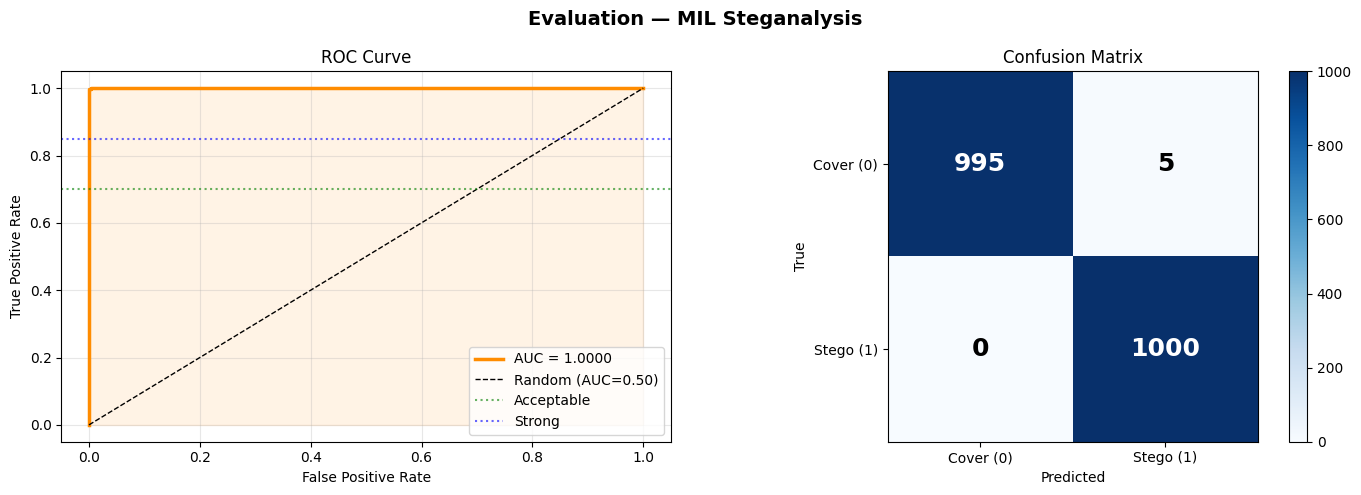

In [64]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluation — MIL Steganalysis', fontsize=14, fontweight='bold')

# ROC
axes[0].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'AUC = {auc:.4f}')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
for lvl, col, lbl in [(0.70,'green','Acceptable'),
                       (0.85,'blue','Strong')]:
    axes[0].axhline(lvl, color=col, linestyle=':', alpha=0.6, label=lbl)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.3)

# Confusion matrix
im = axes[1].imshow(cm, cmap='Blues')
plt.colorbar(im, ax=axes[1])
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(['Cover (0)','Stego (1)'])
axes[1].set_yticks([0,1]); axes[1].set_yticklabels(['Cover (0)','Stego (1)'])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix')
thresh = cm.max()/2
for i in range(2):
    for j in range(2):
        axes[1].text(j,i,format(cm[i,j],'d'),ha='center',va='center',fontsize=18,
                     fontweight='bold',color='white' if cm[i,j]>thresh else 'black')

plt.tight_layout()
plt.savefig(Path(CFG['results_dir'])/'roc_and_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 17 — Attention Weight Visualisation

**Interpretation:** Each image is represented as N patches. The attention weights
show which patches the model found most discriminative. For stego images,
high-attention patches should be the ones containing the most LSB changes.
Red border intensity = attention weight (brighter = higher attention).

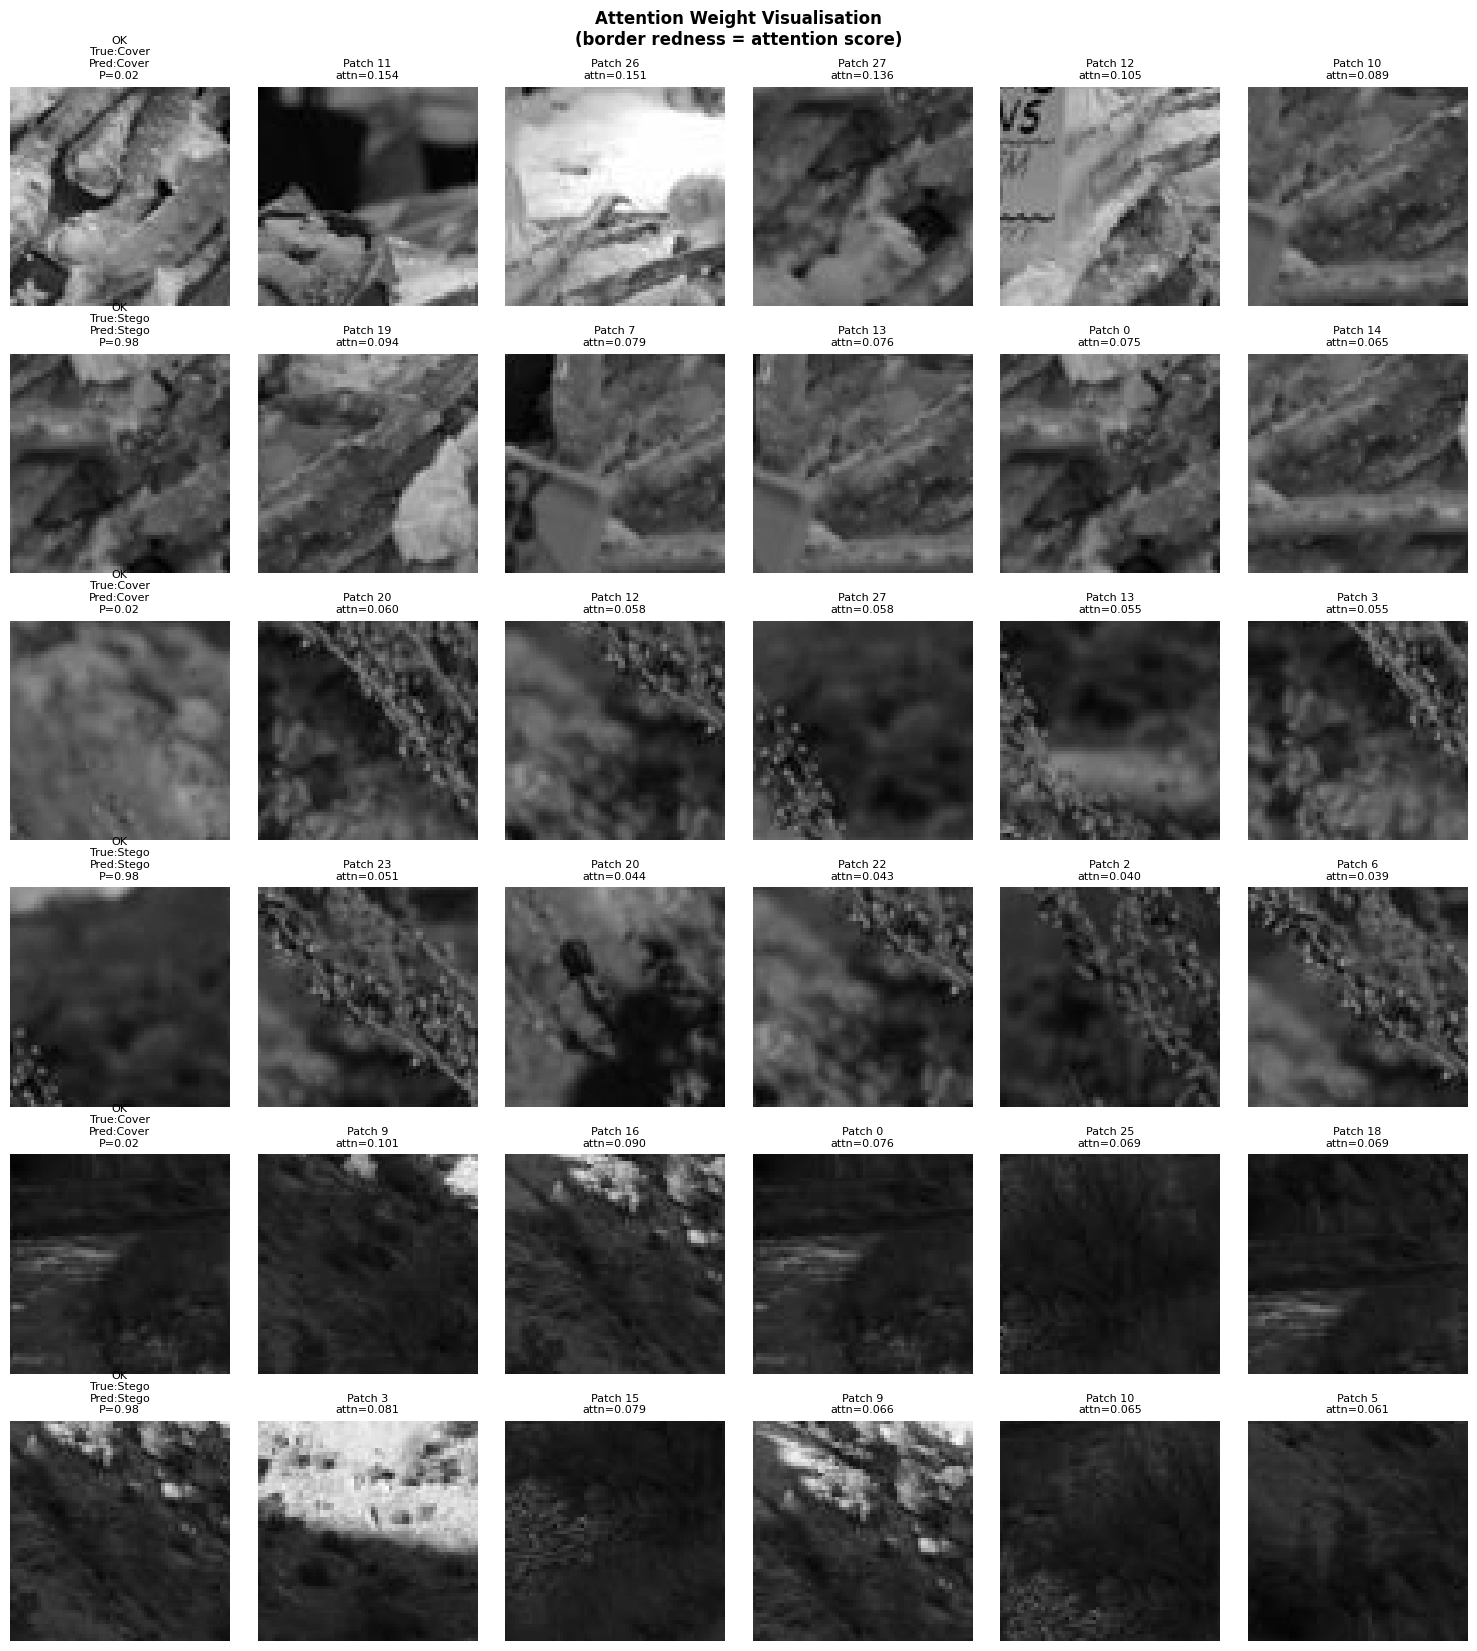

Saved to /kaggle/working/results/attention_map.png


In [65]:
def visualise_attention(model, dataset, indices, device, save_path, top_k=5):
    model.eval()
    n = len(indices)
    fig, axes = plt.subplots(n, top_k+1, figsize=((top_k+1)*2.5, n*2.8))
    if n == 1: axes = axes[np.newaxis,:]
    fig.suptitle('Attention Weight Visualisation\n(border redness = attention score)',
                 fontsize=12, fontweight='bold')
    for row, idx in enumerate(indices):
        bag, label = dataset[idx]
        with torch.no_grad():
            logits, attn = model(bag.unsqueeze(0).to(device))
        prob  = torch.softmax(logits,dim=1)[0,1].item()
        attn  = attn[0].cpu().numpy()
        order = np.argsort(attn)[::-1]
        pred  = 'Stego' if prob>=0.5 else 'Cover'
        truth = 'Stego' if label.item()==1 else 'Cover'
        ok    = 'OK' if pred==truth else 'WRONG'
        axes[row,0].imshow(bag[0,0].numpy(), cmap='gray', vmin=0, vmax=1)
        axes[row,0].set_title(f'{ok}\nTrue:{truth}\nPred:{pred}\nP={prob:.2f}', fontsize=8)
        axes[row,0].axis('off')
        for col, pi in enumerate(order[:top_k]):
            ax = axes[row,col+1]
            ax.imshow(bag[pi,0].numpy(), cmap='gray', vmin=0, vmax=1)
            ax.set_title(f'Patch {pi}\nattn={attn[pi]:.3f}', fontsize=8)
            ax.axis('off')
            intens = min(attn[pi]*CFG['num_patches'], 1.0)
            for sp in ax.spines.values():
                sp.set_edgecolor((intens,0,0)); sp.set_linewidth(3); sp.set_visible(True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {save_path}')


_vis_ds = StegDataset(
    CFG['test_cover_dir'], CFG['test_stego_dir'],
    common_test[:6], CFG['patch_size'], CFG['num_patches_test'], augment=False
)
visualise_attention(
    model, _vis_ds, list(range(min(6, len(_vis_ds)))),
    DEVICE, Path(CFG['results_dir'])/'attention_map.png', top_k=5
)

## Cell 18 — Grad-CAM Visualisation

Grad-CAM highlights which **spatial regions within** a patch drove the CNN's output.
Combined with attention weights (which patches matter most), this gives a two-level
explanation of every prediction:
1. Which patches are suspicious? (attention)
2. Where within each patch is the signal? (Grad-CAM)

grad-cam installed and imported successfully


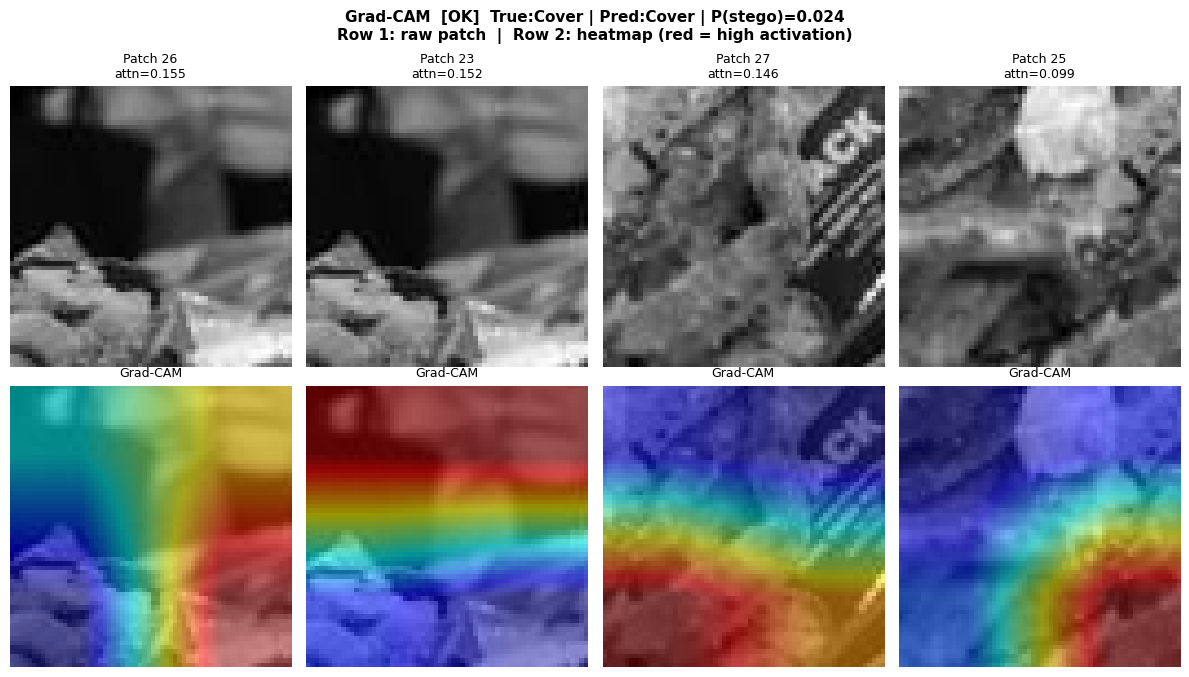

Saved to /kaggle/working/results/gradcam_cover.png


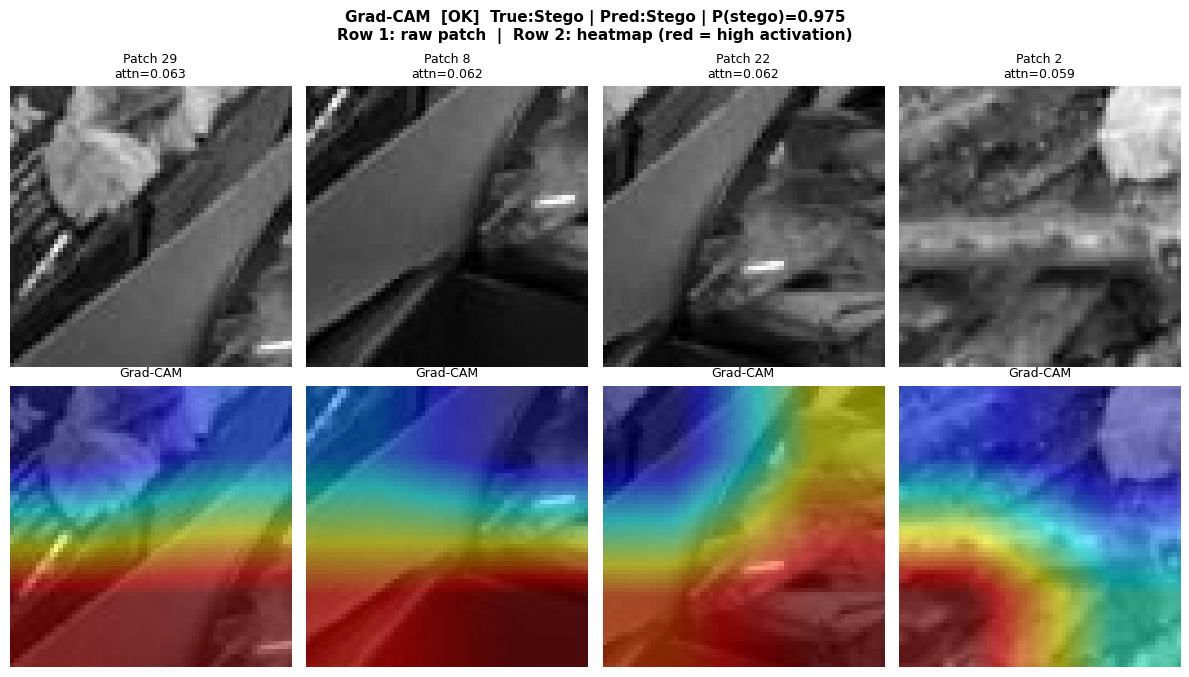

Saved to /kaggle/working/results/gradcam_stego.png
Copied gradcam_cover.png to export folder
Copied gradcam_stego.png to export folder


In [73]:
# Fix: install grad-cam now that internet is enabled
!pip install grad-cam>=1.4.8 --quiet

# Re-import
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    GRADCAM_AVAILABLE = True
    print('grad-cam installed and imported successfully')
except ImportError as e:
    GRADCAM_AVAILABLE = False
    print(f'Still not available: {e}')

# Re-run Grad-CAM visualisation
if GRADCAM_AVAILABLE:
    def visualise_gradcam(model, dataset, idx, device, save_path, top_k=4):
        model.eval()
        bag, label = dataset[idx]
        with torch.no_grad():
            logits, attn = model(bag.unsqueeze(0).to(device))
        prob  = torch.softmax(logits, dim=1)[0, 1].item()
        attn  = attn[0].cpu().numpy()
        order = np.argsort(attn)[::-1]
        truth = 'Stego' if label.item() == 1 else 'Cover'
        pred  = 'Stego' if prob >= 0.5 else 'Cover'
        ok    = 'OK' if pred == truth else 'WRONG'

        target_layers = [model.patch_cnn.backbone.blocks[-1]]
        cam       = GradCAM(model=model.patch_cnn.backbone, target_layers=target_layers)
        srm_layer = model.srm.to(device)

        fig, axes = plt.subplots(2, top_k, figsize=(top_k * 3, 7))
        fig.suptitle(
            f'Grad-CAM  [{ok}]  True:{truth} | Pred:{pred} | P(stego)={prob:.3f}\n'
            f'Row 1: raw patch  |  Row 2: heatmap (red = high activation)',
            fontsize=11, fontweight='bold'
        )

        for col, pi in enumerate(order[:top_k]):
            patch  = bag[pi].to(device)
            srm_p  = srm_layer(patch.unsqueeze(0))
            gc_map = cam(input_tensor=srm_p)

            raw_np  = patch[0].cpu().numpy()
            raw_np  = (raw_np - raw_np.min()) / (raw_np.max() - raw_np.min() + 1e-8)
            raw_rgb = np.stack([raw_np] * 3, axis=-1).astype(np.float32)
            cam_img = show_cam_on_image(raw_rgb, gc_map[0], use_rgb=True)

            axes[0, col].imshow(raw_np, cmap='gray')
            axes[0, col].set_title(f'Patch {pi}\nattn={attn[pi]:.3f}', fontsize=9)
            axes[0, col].axis('off')

            axes[1, col].imshow(cam_img)
            axes[1, col].set_title('Grad-CAM', fontsize=9)
            axes[1, col].axis('off')

        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved to {save_path}')

    # Run on a cover image (idx=0) and a stego image (idx=1)
    for idx, label_name in [(0, 'cover'), (1, 'stego')]:
        visualise_gradcam(
            model     = model,
            dataset   = _vis_ds,
            idx       = idx,
            device    = DEVICE,
            save_path = Path(CFG['results_dir']) / f'gradcam_{label_name}.png',
            top_k     = 4,
        )

    # Also copy the new plots into the export folder
    for png in Path(CFG['results_dir']).glob('gradcam*.png'):
        shutil.copy2(png, Path(CFG['export_dir']) / png.name)
        print(f'Copied {png.name} to export folder')
else:
    print('Installation failed — check internet connection')

## Cell 19 — Score Distribution

A well-calibrated model shows two well-separated peaks:
- Cover scores clustered near 0 (P(stego) low)
- Stego scores clustered near 1 (P(stego) high)

Large overlap between distributions → model is uncertain and accuracy will be near 50%.
The decision threshold (0.5) can be moved to trade off precision vs recall.

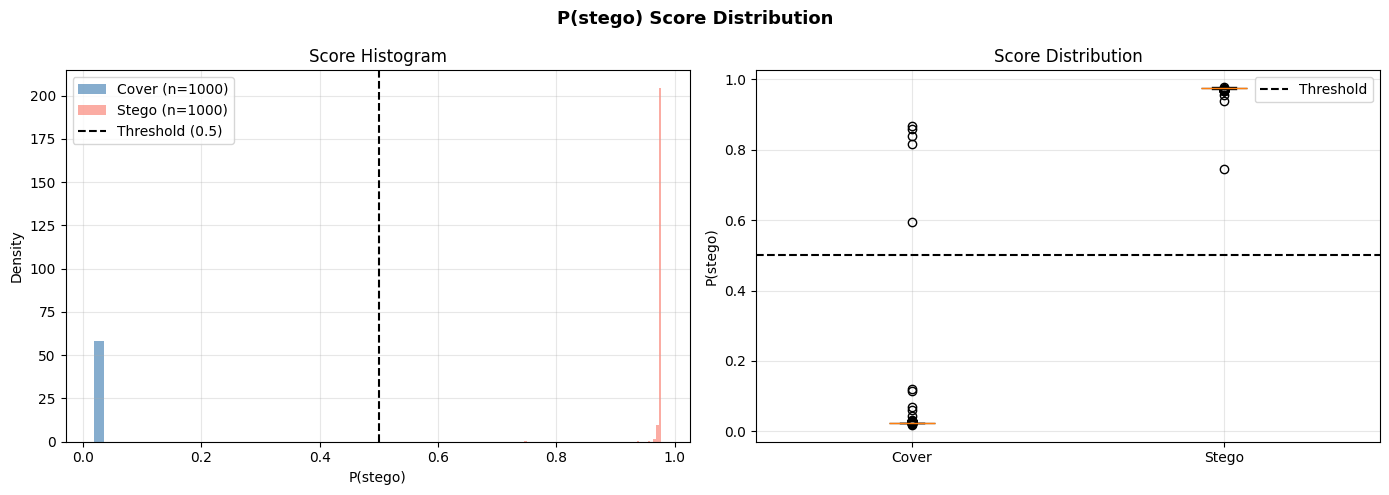

Cover: mean=0.0278  std=0.0550
Stego: mean=0.9750  std=0.0075


In [67]:
cover_scores = all_probs[all_labels==0]
stego_scores = all_probs[all_labels==1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('P(stego) Score Distribution', fontsize=13, fontweight='bold')

axes[0].hist(cover_scores, bins=50, alpha=0.65, color='steelblue',
             label=f'Cover (n={len(cover_scores)})', density=True)
axes[0].hist(stego_scores, bins=50, alpha=0.65, color='salmon',
             label=f'Stego (n={len(stego_scores)})', density=True)
axes[0].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold (0.5)')
axes[0].set_xlabel('P(stego)'); axes[0].set_ylabel('Density')
axes[0].set_title('Score Histogram'); axes[0].legend(); axes[0].grid(alpha=0.3)

bp = axes[1].boxplot([cover_scores, stego_scores], labels=['Cover','Stego'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['steelblue','salmon']):
    patch.set_facecolor(color); patch.set_alpha(0.65)
axes[1].axhline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold')
axes[1].set_ylabel('P(stego)'); axes[1].set_title('Score Distribution')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(Path(CFG['results_dir'])/'score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Cover: mean={cover_scores.mean():.4f}  std={cover_scores.std():.4f}')
print(f'Stego: mean={stego_scores.mean():.4f}  std={stego_scores.std():.4f}')

## Cell 20 — Export Model & Artifacts for Inference

Everything needed to run inference on new images without this notebook:

| File | Contents | Used for |
|---|---|---|
| `best_model.pth` | state_dict + config + metadata | Reload model in Python |
| `model_scripted.pt` | TorchScript trace | Inference without source code |
| `inference_config.json` | all preprocessing params | Know exactly how to preprocess |
| `srm_kernels.npy` | 3 SRM kernel arrays | Apply SRM at inference time |
| `metrics.json` | final evaluation results | Report performance |
| `split.json` | train/test file lists | Reproducibility |
| `history.json` | per-epoch metrics | Reproduce training curves |
| `*.png` | all plots | Report / presentation |

**How to run inference on a new image:**
```python
import torch, json, numpy as np
from PIL import Image
from pathlib import Path

# 1. Load config
cfg = json.load(open('export/inference_config.json'))

# 2. Rebuild model and load weights
model = StegDetector(feature_dim=cfg['feature_dim'],
                     hidden_dim=cfg['hidden_dim'])
ckpt = torch.load('export/best_model.pth', map_location='cpu')
model.load_state_dict(ckpt['model_state'])
model.eval()

# 3. Preprocess image (must be lossless PNG!)
img = np.array(Image.open('test_image.png').convert('L'))
img3 = np.stack([img,img,img], axis=-1)
# Extract patches, build bag tensor (N, 3, patch_size, patch_size)
# ... (see StegDataset.__getitem__)

# 4. Predict
with torch.no_grad():
    logits, attn = model(bag.unsqueeze(0))
    prob_stego = torch.softmax(logits,dim=1)[0,1].item()
print(f'P(stego) = {prob_stego:.4f}  ->  {"STEGO" if prob_stego > 0.5 else "COVER"}')
```

In [69]:
# Cell 20 — Export Model & Artifacts for Inference

export_dir = Path(CFG['export_dir'])
export_dir.mkdir(parents=True, exist_ok=True)

# ── 1. Best model checkpoint (CPU tensors for portability) ─────────────────────
ckpt = torch.load(
    Path(CFG['checkpoint_dir']) / 'best_model.pth',
    map_location='cpu',
    weights_only=False   # required for PyTorch 2.6+ (numpy scalars in cfg dict)
)
model.load_state_dict(ckpt['model_state'])
model.eval()
torch.save({
    'epoch'       : ckpt['epoch'],
    'auc'         : ckpt['auc'],
    'model_state' : {k: v.cpu() for k, v in model.state_dict().items()},
    'architecture': {
        'type'        : 'StegDetector',
        'backbone'    : 'efficientnet_b0',
        'feature_dim' : CFG['feature_dim'],
        'hidden_dim'  : CFG['hidden_dim'],
        'num_classes' : CFG['num_classes'],
        'dropout_rate': CFG['dropout_rate'],
        'description' : 'SRMFilter -> EfficientNet-B0 -> AttentionMIL -> Classifier',
    },
}, export_dir / 'best_model.pth')
print('[1] best_model.pth saved')

# ── 2. TorchScript (no source code needed at inference) ────────────────────────
try:
    model_cpu = model.cpu().eval()
    dummy  = torch.randn(1, CFG['num_patches_test'], 3, CFG['patch_size'], CFG['patch_size'])
    traced = torch.jit.trace(model_cpu, dummy, strict=False)
    traced.save(str(export_dir / 'model_scripted.pt'))
    print('[2] model_scripted.pt saved')
except Exception as e:
    print(f'[2] TorchScript skipped: {e}')
model = model.to(DEVICE)

# ── 3. Inference config ────────────────────────────────────────────────────────
inference_config = {
    'model_class'     : 'StegDetector',
    'backbone'        : 'efficientnet_b0',
    'feature_dim'     : CFG['feature_dim'],
    'hidden_dim'      : CFG['hidden_dim'],
    'num_classes'     : CFG['num_classes'],
    'dropout_rate'    : CFG['dropout_rate'],
    'patch_size'      : CFG['patch_size'],
    'num_patches'     : CFG['num_patches_test'],
    'input_channels'  : 3,
    'input_range'     : '[0, 1] float32',
    'srm_inside_model': True,
    'image_format'    : 'lossless PNG only (JPEG will fail — JPEG noise masks LSB signal)',
    'grayscale_to_3ch': 'replicate: stack([L,L,L], axis=-1)',
    'embedding_type'  : 'LSB replacement',
    'payload_rate_bpp': CFG['payload_rate'],
    'best_epoch'      : int(ckpt['epoch']),
    'best_auc'        : float(ckpt['auc']),
    'checkpoint_file' : 'best_model.pth',
    'phase1_epochs'   : CFG['phase1_epochs'],
    'lr_phase1'       : CFG['lr_phase1'],
    'lr_phase2'       : CFG['lr_phase2'],
    'label_smoothing' : CFG['label_smoothing'],
    'weight_decay'    : CFG['weight_decay'],
    'early_stopping'  : f'patience={CFG["es_patience"]}, min_delta={CFG["es_min_delta"]}',
}
with open(export_dir / 'inference_config.json', 'w') as f:
    json.dump(inference_config, f, indent=2)
print('[3] inference_config.json saved')

# ── 4. SRM kernels ─────────────────────────────────────────────────────────────
np.save(str(export_dir / 'srm_kernels.npy'), get_srm_kernels())
print('[4] srm_kernels.npy saved')

# ── 5. Copy metrics, history, split, plots ─────────────────────────────────────
for src in [Path(CFG['results_dir']) / 'metrics.json',
            Path(CFG['work_dir'])    / 'history.json',
            Path(CFG['work_dir'])    / 'split.json']:
    if src.exists():
        shutil.copy2(src, export_dir / src.name)
for png in Path(CFG['results_dir']).glob('*.png'):
    shutil.copy2(png, export_dir / png.name)
print('[5] metrics, history, split, plots copied')

print()
print('EXPORT CONTENTS:')
print('━'*55)
for f in sorted(export_dir.iterdir()):
    print(f'  {f.name:<35} {f.stat().st_size/1024:>8.1f} KB')
print('━'*55)

[1] best_model.pth saved
[2] model_scripted.pt saved
[3] inference_config.json saved
[4] srm_kernels.npy saved
[5] metrics, history, split, plots copied

EXPORT CONTENTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  attention_map.png                      414.0 KB
  best_model.pth                       19281.3 KB
  history.json                             2.1 KB
  inference_config.json                    0.7 KB
  metrics.json                             0.1 KB
  model_scripted.pt                    19839.8 KB
  roc_and_confusion.png                   97.0 KB
  sample_patches.png                      91.9 KB
  score_distribution.png                  72.7 KB
  split.json                             155.2 KB
  srm_kernels.npy                          0.4 KB
  srm_visualisation.png                  727.6 KB
  training_curves.png                    167.5 KB
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## Cell 21 — Final Summary

In [70]:
print('╔' + '═'*62 + '╗')
print('║  MIL STEGANALYSIS — EXPERIMENT SUMMARY                      ║')
print('╠' + '═'*62 + '╣')
print(f'║  Problem         : LSB steganalysis (binary classification)  ║')
print(f'║  Dataset         : BOSSbase 1.01, LSB 0.4 bpp, 256x256 px   ║')
print(f'║  Data fix        : JPEG->lossless PNG (critical for signal)  ║')
print(f'║  Architecture    : SRM -> EfficientNet-B0 -> Attention MIL  ║')
print(f'║  Patch size      : {CFG["patch_size"]}x{CFG["patch_size"]} px  |  Bag: {CFG["num_patches"]} train / {CFG["num_patches_test"]} test      ║')
print(f'║  Training        : 2-phase (freeze/unfreeze) + early stop   ║')
print(f'║  Regularisation  : BN + Dropout + L2 + label smooth + clip  ║')
print(f'║  Best epoch      : {best_epoch:<3}  (early stopping patience={PATIENCE})          ║')
print('╠' + '═'*62 + '╣')
print(f'║  AUC-ROC         : {auc:.4f}  (primary metric)                ║')
print(f'║  Accuracy        : {acc:.4f}                                   ║')
print(f'║  F1 Score        : {f1:.4f}                                   ║')
print('╠' + '═'*62 + '╣')
print(f'║  Exported to     : {CFG["export_dir"][:40]}   ║')
print('╚' + '═'*62 + '╝')
print()
print('AUC interpretation guide:')
for lvl, desc in [(0.90,'Excellent — state-of-the-art'),
                  (0.85,'Strong    — competitive with literature'),
                  (0.80,'Good      — solid detection'),
                  (0.70,'Acceptable— some learning'),
                  (0.60,'Weak      — barely above chance'),
                  (0.50,'Random    — model learned nothing')]:
    marker = '<- YOU ARE HERE' if lvl <= auc < lvl+0.10 else ''
    print(f'  {lvl:.2f}  {desc}  {marker}')

╔══════════════════════════════════════════════════════════════╗
║  MIL STEGANALYSIS — EXPERIMENT SUMMARY                      ║
╠══════════════════════════════════════════════════════════════╣
║  Problem         : LSB steganalysis (binary classification)  ║
║  Dataset         : BOSSbase 1.01, LSB 0.4 bpp, 256x256 px   ║
║  Data fix        : JPEG->lossless PNG (critical for signal)  ║
║  Architecture    : SRM -> EfficientNet-B0 -> Attention MIL  ║
║  Patch size      : 64x64 px  |  Bag: 20 train / 30 test      ║
║  Training        : 2-phase (freeze/unfreeze) + early stop   ║
║  Regularisation  : BN + Dropout + L2 + label smooth + clip  ║
║  Best epoch      : 20   (early stopping patience=5)          ║
╠══════════════════════════════════════════════════════════════╣
║  AUC-ROC         : 1.0000  (primary metric)                ║
║  Accuracy        : 0.9975                                   ║
║  F1 Score        : 0.9975                                   ║
╠═════════════════════════════════

In [72]:
# ── Download everything — run this as the very last cell ──────────────────────
import zipfile
import shutil
from pathlib import Path

# ── Step 1: Create a single zip of the entire export folder ───────────────────
zip_path = '/kaggle/working/steganalysis_complete_export.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(Path(CFG['export_dir']).iterdir()):
        zf.write(f, arcname=f'export/{f.name}')
        print(f'  Added: {f.name}  ({f.stat().st_size/1024:.1f} KB)')

print()
print(f'Zip created: {zip_path}')
print(f'Zip size   : {Path(zip_path).stat().st_size/1024/1024:.1f} MB')

# ── Step 2: Also copy the notebook itself into the zip ────────────────────────
# Kaggle saves the committed notebook to /kaggle/working/
notebooks = list(Path('/kaggle/working').glob('*.ipynb'))
if notebooks:
    with zipfile.ZipFile(zip_path, 'a', zipfile.ZIP_DEFLATED) as zf:
        for nb in notebooks:
            zf.write(nb, arcname=f'notebook/{nb.name}')
            print(f'  Added notebook: {nb.name}')

# ── Step 3: Print download instructions ───────────────────────────────────────
print()
print('━'*55)
print('  HOW TO DOWNLOAD')
print('━'*55)
print('  1. Go to Kaggle notebook page')
print('  2. Click the Output tab (top right of notebook)')
print('  3. Find: steganalysis_complete_export.zip')
print('  4. Click the download arrow next to it')
print('━'*55)
print()
print('  ZIP CONTENTS:')
with zipfile.ZipFile(zip_path, 'r') as zf:
    for name in sorted(zf.namelist()):
        info = zf.getinfo(name)
        print(f'    {name:<50} {info.file_size/1024:>8.1f} KB')
print('━'*55)

  Added: attention_map.png  (414.0 KB)
  Added: best_model.pth  (19281.3 KB)
  Added: history.json  (2.1 KB)
  Added: inference_config.json  (0.7 KB)
  Added: metrics.json  (0.1 KB)
  Added: model_scripted.pt  (19839.8 KB)
  Added: roc_and_confusion.png  (97.0 KB)
  Added: sample_patches.png  (91.9 KB)
  Added: score_distribution.png  (72.7 KB)
  Added: split.json  (155.2 KB)
  Added: srm_kernels.npy  (0.4 KB)
  Added: srm_visualisation.png  (727.6 KB)
  Added: training_curves.png  (167.5 KB)

Zip created: /kaggle/working/steganalysis_complete_export.zip
Zip size   : 36.6 MB

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  HOW TO DOWNLOAD
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. Go to Kaggle notebook page
  2. Click the Output tab (top right of notebook)
  3. Find: steganalysis_complete_export.zip
  4. Click the download arrow next to it
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ZIP CONTENTS:
    export/attention_map.png                   

In [74]:
# Update the zip with the new Grad-CAM plots
import zipfile
from pathlib import Path

zip_path = '/kaggle/working/steganalysis_complete_export.zip'

with zipfile.ZipFile(zip_path, 'a', zipfile.ZIP_DEFLATED) as zf:
    for png in Path(CFG['results_dir']).glob('gradcam*.png'):
        zf.write(png, arcname=f'export/{png.name}')
        print(f'Added to zip: {png.name}')

print('Zip updated.')

Added to zip: gradcam_cover.png
Added to zip: gradcam_stego.png
Zip updated.


In [75]:
# Audit all expected plots
expected = [
    'srm_visualisation.png',   # SRM residual diff (cover vs stego)
    'sample_patches.png',      # sample patches from DataLoader
    'training_curves.png',     # loss / accuracy / AUC over epochs
    'roc_and_confusion.png',   # ROC curve + confusion matrix
    'attention_map.png',       # attention weights on test images
    'score_distribution.png',  # P(stego) histogram cover vs stego
    'gradcam_cover.png',       # Grad-CAM on a cover image
    'gradcam_stego.png',       # Grad-CAM on a stego image
]

print('Plot audit:')
print('━'*45)
for name in expected:
    path = Path(CFG['results_dir']) / name
    if path.exists():
        print(f'  OK  {name}  ({path.stat().st_size/1024:.0f} KB)')
    else:
        print(f'  MISSING  {name}')
print('━'*45)

Plot audit:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  OK  srm_visualisation.png  (728 KB)
  OK  sample_patches.png  (92 KB)
  OK  training_curves.png  (168 KB)
  OK  roc_and_confusion.png  (97 KB)
  OK  attention_map.png  (414 KB)
  OK  score_distribution.png  (73 KB)
  OK  gradcam_cover.png  (132 KB)
  OK  gradcam_stego.png  (131 KB)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
